# 03 - ML Approach Search (US-China)

Systematic search for best DML-IV approach given small sample (~386 obs).

Goal: find ML method that matches or beats linear LP-IV baseline.

In [9]:
from pathlib import Path
import importlib.util
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, ElasticNetCV, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import TimeSeriesSplit

ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
MODULE_PATH = ROOT / "replication" / "saadaoui_replication.py"
spec = importlib.util.spec_from_file_location("saadaoui_replication", MODULE_PATH)
rep = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = rep
spec.loader.exec_module(rep)
print("Loaded:", MODULE_PATH)

Loaded: c:\Users\HP\Desktop\replication+contribution\replication\saadaoui_replication.py


In [10]:
def crossfit_residuals(y, t, z, x, model_y, model_t, model_z, n_splits=5):
    """Cross-fit residuals using TimeSeriesSplit."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    y_res = np.full(len(y), np.nan)
    t_res = np.full(len(t), np.nan)
    z_res = np.full(len(z), np.nan)

    for tr_idx, te_idx in tscv.split(x):
        x_tr, x_te = x[tr_idx], x[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]
        t_tr, t_te = t[tr_idx], t[te_idx]
        z_tr, z_te = z[tr_idx], z[te_idx]

        my = clone(model_y).fit(x_tr, y_tr)
        mt = clone(model_t).fit(x_tr, t_tr)
        mz = clone(model_z).fit(x_tr, z_tr)

        y_res[te_idx] = y_te - my.predict(x_te)
        t_res[te_idx] = t_te - mt.predict(x_te)
        z_res[te_idx] = z_te - mz.predict(x_te)

    valid = np.isfinite(y_res) & np.isfinite(t_res) & np.isfinite(z_res)
    return y_res[valid], t_res[valid], z_res[valid]


def fstat_simple(y, x):
    """Simple first-stage F stat."""
    if len(y) < 5:
        return np.nan
    X = np.column_stack([np.ones(len(x)), x])
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    yhat = X @ b
    sse_u = float(np.sum((y - yhat) ** 2))
    sse_r = float(np.sum((y - np.mean(y)) ** 2))
    n, k_u = len(y), 2
    if n <= k_u or sse_u <= 0:
        return np.nan
    f = ((sse_r - sse_u) / 1.0) / (sse_u / (n - k_u))
    return max(0.0, float(f))


def dml_path(df, x_cols, model_y, model_t, model_z, hmax=48):
    """Run DML-IV for all horizons."""
    rows = []
    for h in range(hmax + 1):
        d = pd.DataFrame({
            "y_fwd": df["lwti"].shift(-h),
            "t": df["lpri"],
            "z": df["d2pri"],
            **{c: df[c] for c in x_cols},
        }).replace([np.inf, -np.inf], np.nan).dropna()

        if len(d) < 80:
            rows.append({"h": h, "beta_wald": np.nan, "first_stage_f": np.nan, "weak_iv": True, "n_obs": len(d)})
            continue

        y = d["y_fwd"].to_numpy()
        t = d["t"].to_numpy()
        z = d["z"].to_numpy()
        x = d[x_cols].to_numpy()

        y_res, t_res, z_res = crossfit_residuals(y, t, z, x, model_y, model_t, model_z, n_splits=5)
        varz = float(np.var(z_res)) if len(z_res) else 0.0
        if len(y_res) < 60 or varz <= 0:
            rows.append({"h": h, "beta_wald": np.nan, "first_stage_f": np.nan, "weak_iv": True, "n_obs": len(d)})
            continue

        alpha = float(np.cov(y_res, z_res, ddof=0)[0, 1] / varz)
        gamma = float(np.cov(t_res, z_res, ddof=0)[0, 1] / varz)
        f = fstat_simple(t_res, z_res)
        weak = (not np.isfinite(f)) or (f < 10.0) or (abs(gamma) < 0.05)
        beta = np.nan if weak else float(alpha / gamma)
        rows.append({"h": h, "beta_wald": beta, "first_stage_f": f, "weak_iv": weak, "n_obs": len(d)})
    return pd.DataFrame(rows)

In [11]:
p = rep.locate_paths()
df = rep.ensure_derived_columns(rep.load_data(p.dta, cache_path=p.cache / "Saadaoui_2026_JCE.parquet"))
base_controls = ["llwip", "dllgop", "l2lwip", "dl2lgop"]
work, lag_cols = rep.add_lagged_controls(df, y_col="lwti", shock_col="lpri", y_lags=3, shock_lags=2)
x_cols = lag_cols + base_controls

baseline = rep.lp_iv(df, "lpri", "d2pri", base_controls)
stata_path = rep.parse_stata_log(p.log)["iv_lpri"]

print(f"Sample size: {len(work)} obs")
print(f"X cols ({len(x_cols)}): {x_cols}")
print(f"Baseline has {len(baseline)} horizons")

Sample size: 386 obs
X cols (9): ['L1_lwti', 'L2_lwti', 'L3_lwti', 'L1_lpri', 'L2_lpri', 'llwip', 'dllgop', 'l2lwip', 'dl2lgop']
Baseline has 49 horizons


In [13]:
import numpy as np
import pandas as pd
from sklearn.linear_model import (
    LinearRegression, Ridge, LassoCV, ElasticNetCV, BayesianRidge
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

def mae_rmse(a, b):
    d = a - b
    return float(np.mean(np.abs(d))), float(np.sqrt(np.mean(d**2)))

models_to_test = {
    "LinearRegression": (LinearRegression(), LinearRegression(), LinearRegression()),
    "Ridge_a0.01": (Ridge(alpha=0.01), Ridge(alpha=0.01), Ridge(alpha=0.01)),
    "Ridge_a0.1": (Ridge(alpha=0.1), Ridge(alpha=0.1), Ridge(alpha=0.1)),
    "Ridge_a1": (Ridge(alpha=1.0), Ridge(alpha=1.0), Ridge(alpha=1.0)),
    "Ridge_a10": (Ridge(alpha=10.0), Ridge(alpha=10.0), Ridge(alpha=10.0)),
    "Ridge_a100": (Ridge(alpha=100.0), Ridge(alpha=100.0), Ridge(alpha=100.0)),
    # FIXED: Changed Lasso to LassoCV and cleaned up the trailing text
    "Lasso_cv": (LassoCV(cv=5, random_state=42, max_iter=20000), 
                 LassoCV(cv=5, random_state=42, max_iter=20000), 
                 LassoCV(cv=5, random_state=42, max_iter=20000)),
    "ElasticNet_cv": (ElasticNetCV(cv=5, random_state=42, max_iter=20000), 
                      ElasticNetCV(cv=5, random_state=42, max_iter=20000), 
                      ElasticNetCV(cv=5, random_state=42, max_iter=20000)),
    "BayesianRidge": (BayesianRidge(), BayesianRidge(), BayesianRidge()),
    "KNN_3": (KNeighborsRegressor(n_neighbors=3), KNeighborsRegressor(n_neighbors=3), KNeighborsRegressor(n_neighbors=3)),
    "KNN_5": (KNeighborsRegressor(n_neighbors=5), KNeighborsRegressor(n_neighbors=5), KNeighborsRegressor(n_neighbors=5)),
    "KNN_10": (KNeighborsRegressor(n_neighbors=10), KNeighborsRegressor(n_neighbors=10), KNeighborsRegressor(n_neighbors=10)),
    "RF_shallow": (RandomForestRegressor(n_estimators=100, max_depth=2, random_state=42), 
                   RandomForestRegressor(n_estimators=100, max_depth=2, random_state=42), 
                   RandomForestRegressor(n_estimators=100, max_depth=2, random_state=42)),
    "RF_tree": (RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42), 
                RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42), 
                RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42)),
    "GB_shallow": (GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.01, random_state=42), 
                   GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.01, random_state=42), 
                   GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.01, random_state=42)),
}

results = []
for name, (my, mt, mz) in models_to_test.items():
    print(f"Testing: {name}...", end=" ")
    try:
        # Assuming work, x_cols, dml_path, baseline, and stata_path are defined elsewhere
        dml_df = dml_path(work, x_cols, my, mt, mz)
        valid = dml_df.dropna(subset=["beta_wald"]).merge(baseline[["h", "coef"]], on="h", how="inner")
        
        if len(valid) > 0:
            mae_bl, rmse_bl = mae_rmse(valid["beta_wald"].to_numpy(), valid["coef"].to_numpy())
            common_h = sorted(set(valid["h"].astype(int)).intersection(stata_path.keys()))
            dml_vals = np.array([float(valid.loc[valid["h"] == h, "beta_wald"].iloc[0]) for h in common_h])
            stata_vals = np.array([stata_path[h] for h in common_h])
            mae_st, rmse_st = mae_rmse(dml_vals, stata_vals)
            
            weak_share = dml_df["weak_iv"].mean()
            median_f = dml_df["first_stage_f"].median()
            min_f = dml_df["first_stage_f"].min()
            
            results.append({
                "model": name,
                "weak_iv_share": weak_share,
                "median_f": median_f,
                "min_f": min_f,
                "mae_vs_baseline": mae_bl,
                "rmse_vs_baseline": rmse_bl,
                "mae_vs_stata": mae_st,
                "rmse_vs_stata": rmse_st,
                "n_valid_horizons": len(valid),
            })
            print(f"weak={weak_share:.1%}, F={median_f:.1f}, MAE(baseline)={mae_bl:.4f}, MAE(stata)={mae_st:.4f}")
        else:
            print("no valid horizons")
    except Exception as e:
        print(f"ERROR: {e}")

results_df = pd.DataFrame(results)
if not results_df.empty:
    results_df = results_df.sort_values("mae_vs_baseline")
    print("\n=== Results sorted by MAE vs baseline ===")
    print(results_df)
else:
    print("\nNo results found.")

Testing: LinearRegression... weak=0.0%, F=2115.6, MAE(baseline)=0.1408, MAE(stata)=0.1391
Testing: Ridge_a0.01... weak=0.0%, F=2093.6, MAE(baseline)=0.1654, MAE(stata)=0.1638
Testing: Ridge_a0.1... weak=0.0%, F=1368.8, MAE(baseline)=0.1629, MAE(stata)=0.1612
Testing: Ridge_a1... weak=0.0%, F=295.7, MAE(baseline)=0.1988, MAE(stata)=0.2004
Testing: Ridge_a10... weak=0.0%, F=52.2, MAE(baseline)=0.1032, MAE(stata)=0.1015
Testing: Ridge_a100... no valid horizons
Testing: Lasso_cv... weak=0.0%, F=1197.4, MAE(baseline)=0.2633, MAE(stata)=0.2650
Testing: ElasticNet_cv... weak=0.0%, F=1203.2, MAE(baseline)=0.2413, MAE(stata)=0.2430
Testing: BayesianRidge... weak=0.0%, F=1774.1, MAE(baseline)=0.1761, MAE(stata)=0.1744
Testing: KNN_3... weak=14.3%, F=24.0, MAE(baseline)=0.2809, MAE(stata)=0.2809
Testing: KNN_5... weak=30.6%, F=16.8, MAE(baseline)=0.2799, MAE(stata)=0.2775
Testing: KNN_10... no valid horizons
Testing: RF_shallow... no valid horizons
Testing: RF_tree... weak=89.8%, F=3.8, MAE(basel

In [14]:
outdir = ROOT / "results" / "ml_benchmarks"
outdir.mkdir(parents=True, exist_ok=True)
results_df.to_csv(outdir / "ml_approach_search.csv", index=False)
print("Saved to", outdir / "ml_approach_search.csv")

Saved to c:\Users\HP\Desktop\replication+contribution\results\ml_benchmarks\ml_approach_search.csv


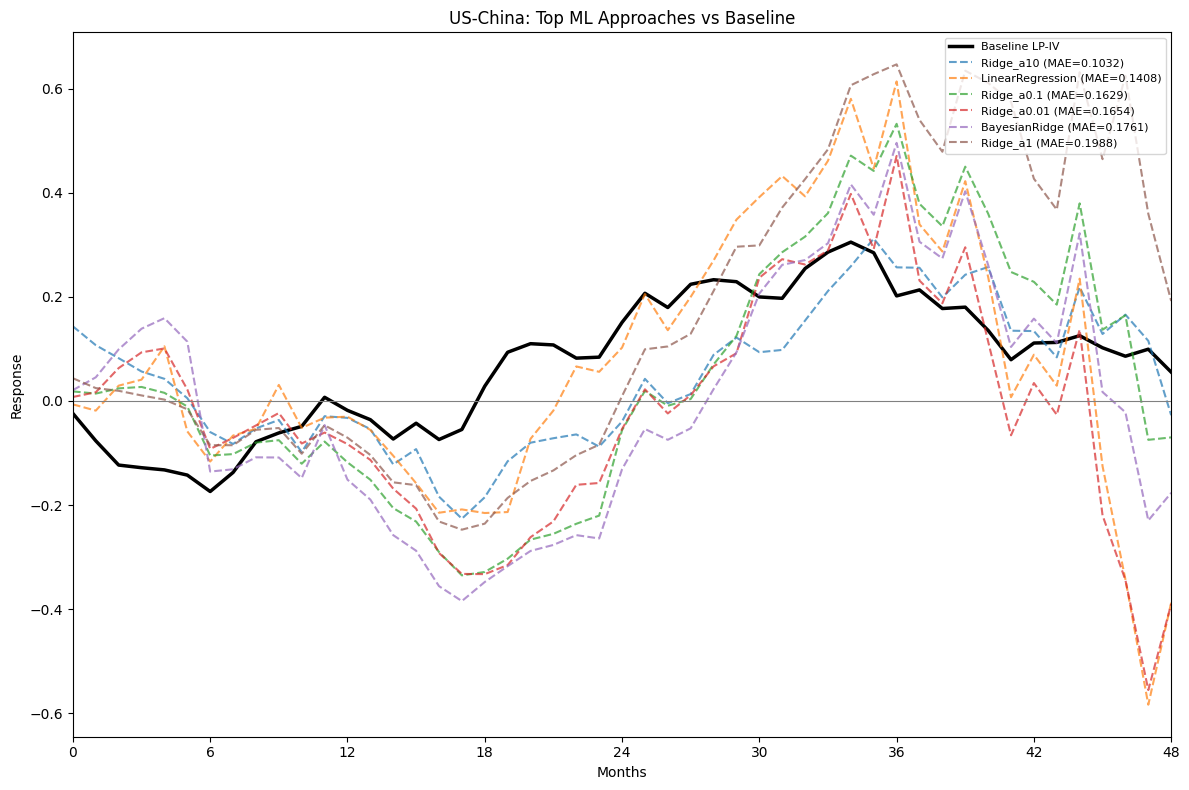

Saved: c:\Users\HP\Desktop\replication+contribution\figures\ml_approach_search.png


In [15]:
plt.figure(figsize=(12, 8))
plt.plot(baseline["h"], baseline["coef"], label="Baseline LP-IV", linewidth=2.5, color="black")

for i, row in results_df.head(6).iterrows():
    name = row["model"]
    my, mt, mz = models_to_test[name]
    dml_df = dml_path(work, x_cols, my, mt, mz)
    plt.plot(dml_df["h"], dml_df["beta_wald"], label=f"{name} (MAE={row['mae_vs_baseline']:.4f})", linestyle="--", alpha=0.7)

plt.axhline(0, color="gray", linewidth=0.8)
plt.xlim(0, 48)
plt.xticks(np.arange(0, 49, 6))
plt.xlabel("Months")
plt.ylabel("Response")
plt.title("US-China: Top ML Approaches vs Baseline")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
fig_path = ROOT / "figures" / "ml_approach_search.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

In [16]:
print("=== Summary ===")
print(f"Best by MAE vs baseline: {results_df.iloc[0]['model']}")
print(f"Best by MAE vs Stata: {results_df.sort_values('mae_vs_stata').iloc[0]['model']}")
print(f"Best stability (lowest weak-IV): {results_df.sort_values('weak_iv_share').iloc[0]['model']}")
print(f"\nInterpretation:")
print("- LinearRegression should match baseline exactly (sanity check)")
print("- Regularized versions may help or hurt depending on sample size")
print("- KNN/RF/GB add non-linearity but may overfit in small samples")

=== Summary ===
Best by MAE vs baseline: Ridge_a10
Best by MAE vs Stata: Ridge_a10
Best stability (lowest weak-IV): Ridge_a10

Interpretation:
- LinearRegression should match baseline exactly (sanity check)
- Regularized versions may help or hurt depending on sample size
- KNN/RF/GB add non-linearity but may overfit in small samples
